### 1. Import packages

In [ ]:
import os, time, math
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix

import warnings
warnings.filterwarnings("ignore")

from art.attacks.evasion import (
    ZooAttack, HopSkipJump
)
from art.estimators.classification import SklearnClassifier

sys.path.insert(0, os.path.abspath('..'))
# from utils.masking import get_mutate_indices, generate_masked

### 2. Load data and trained model

In [19]:
# Load trained RandomForest model
rf_model = joblib.load('../../training/models/framework_rf_TVAE.pkl')

# Load test data
df_test = pd.read_csv('../../datasets/test_shap_66.csv')
X_test = df_test.drop(columns=['Label']).values
y_test = df_test['Label'].values.astype(int)

In [ ]:
# Detect binary/categorical features to protect during adversarial generation
mutate_indices = get_mutate_indices(df_test)
print(f'Protected features ({len(mutate_indices)}): {[df_test.columns[i] for i in mutate_indices]}')
print(f'Perturbable features: {X_test.shape[1] - len(mutate_indices)}/{X_test.shape[1]}')

### 3. Original model prediction

Original Accuracy: 86.09%
Original Precision: 86.18%
Original Recall: 86.09%
Original F1 Score: 0.8581


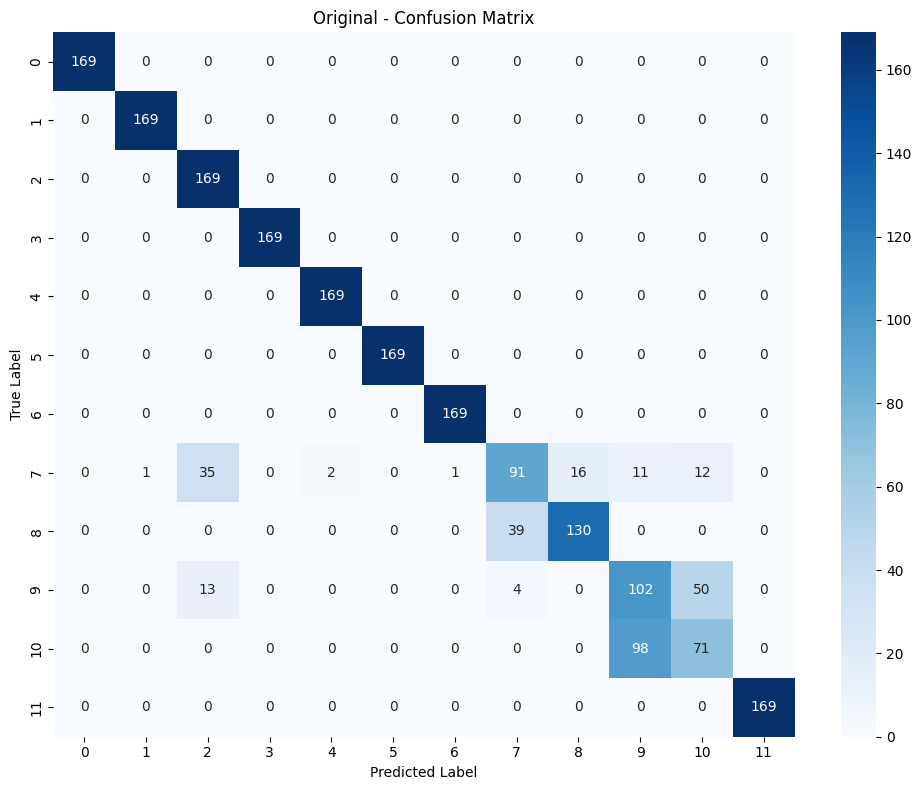

In [3]:
original_preds = rf_model.predict_proba(df_test[df_test.columns[:-1]])
original_preds = np.argmax(original_preds, axis=1)

original_accuracy = accuracy_score(y_test, original_preds) * 100
original_f1 = f1_score(y_test, original_preds, average='weighted')
original_precision = precision_score(y_test, original_preds, average='weighted') * 100
original_recall = recall_score(y_test, original_preds, average='weighted') * 100

print(f'Original Accuracy: {original_accuracy:.2f}%')
print(f'Original Precision: {original_precision:.2f}%')
print(f'Original Recall: {original_recall:.2f}%')
print(f'Original F1 Score: {original_f1:.4f}')

cm = confusion_matrix(y_test, original_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Original - Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

In [20]:
# Create ART classifier
classifier = SklearnClassifier(
    model=rf_model,
    clip_values=(np.min(X_test), np.max(X_test)),
)

predictions = classifier.predict(X_test)
predictions = np.argmax(predictions, axis=1)
accuracy = accuracy_score(y_test, predictions)
print(f'ART Classifier Accuracy: {accuracy * 100:.2f}%')

ART Classifier Accuracy: 86.09%


### 4. Generate adversarial samples

In [21]:
def evaluate_attack(y_test, y_pred, attack_name):
    predictions = np.argmax(y_pred, axis=1)

    accuracy = accuracy_score(y_test, predictions) * 100
    f1 = f1_score(y_test, predictions, average='macro')
    precision = precision_score(y_test, predictions, average='macro') * 100
    recall = recall_score(y_test, predictions, average='macro') * 100

    print(f'--- {attack_name} ---')
    print(f'Accuracy on {attack_name} adversarial examples: {accuracy:.2f}%')
    print(f'Precision on {attack_name} adversarial examples: {precision:.2f}%')
    print(f'Recall on {attack_name} adversarial examples: {recall:.2f}%')
    print(f'F1 Score on {attack_name} adversarial examples: {f1:.4f}')

    cm = confusion_matrix(y_test, predictions)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'{attack_name} - Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.tight_layout()
    plt.show()

attack = ZooAttack(
    classifier=classifier,
    confidence=0.0,
    targeted=False,
    learning_rate=1e-1,
    max_iter=30,
    binary_search_steps=3,
    initial_const=1e-3,
    abort_early=True,
    use_resize=False,
    use_importance=False,
    nb_parallel=10,
    batch_size=1,
    variable_h=0.02,
)

start_time = time.time()
ZOO_adv_samples = generate_masked(attack, X_test, mutate_indices, use_mask=False)

In [25]:
attack = ZooAttack(
    classifier=classifier,
    confidence=0.0,
    targeted=False,
    learning_rate=1e-1,
    max_iter=30,
    binary_search_steps=3,
    initial_const=1e-3,
    abort_early=True,
    use_resize=False,
    use_importance=False,
    nb_parallel=10,
    batch_size=1,
    variable_h=0.02,
)

start_time = time.time()
ZOO_adv_samples = attack.generate(x=X_test)

ZOO: 100%|██████████| 2028/2028 [12:25<00:00,  2.72it/s]


--- ZOO ---
Accuracy on ZOO adversarial examples: 41.37%
Precision on ZOO adversarial examples: 42.22%
Recall on ZOO adversarial examples: 41.37%
F1 Score on ZOO adversarial examples: 0.3968


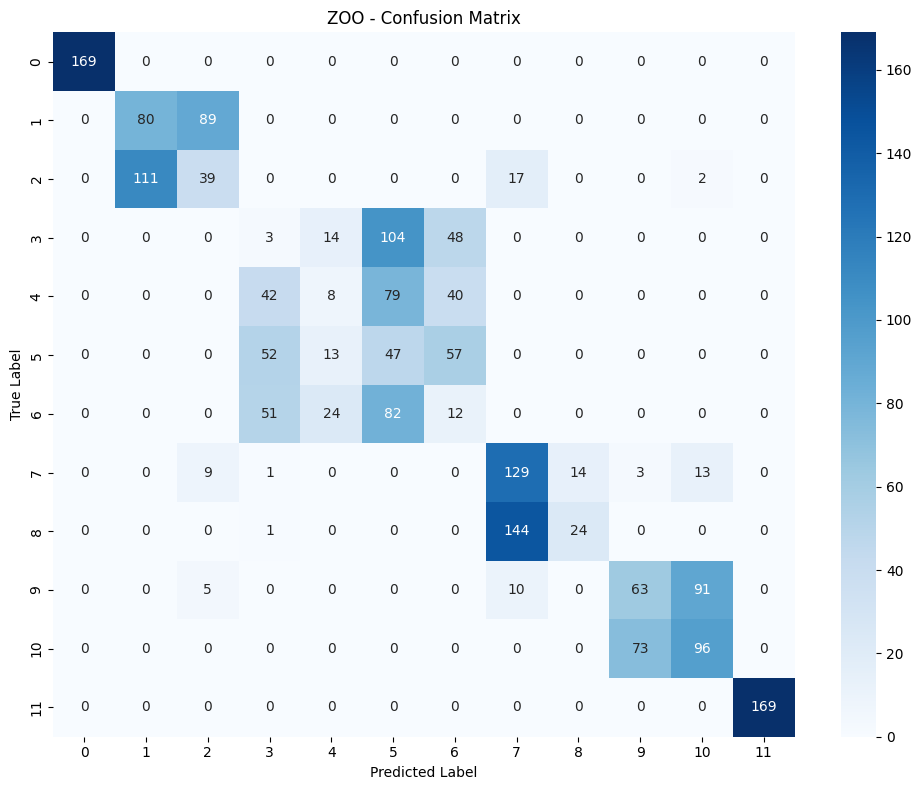

Runtime:  748.8895840644836  seconds


In [26]:
predictions_adv = classifier.predict(ZOO_adv_samples)

evaluate_attack(y_test, predictions_adv, 'ZOO')
print("Runtime: ", time.time() - start_time, " seconds")

# Save adversarial samples as CSV
feature_names = df_test.columns[:-1].tolist()
df_adv = pd.DataFrame(ZOO_adv_samples, columns=feature_names)
df_adv['Label'] = y_test
df_adv.to_csv('../../adv_samples/adv_eval/rf/rf_zoo_adv.csv', index=False)

HSJA

In [28]:
attack = HopSkipJump(
    classifier=classifier,
    batch_size=64,
    targeted=False,
    norm=2,
    max_iter=5,
    max_eval=100,
    init_eval=10,
    init_size=10,
    verbose=True,
)

start_time = time.time()
HSJA_adv_samples = attack.generate(x=X_test)

HopSkipJump: 100%|██████████| 2028/2028 [33:56<00:00,  1.00s/it]


--- HSJA ---
Accuracy on HSJA adversarial examples: 16.07%
Precision on HSJA adversarial examples: 10.15%
Recall on HSJA adversarial examples: 16.07%
F1 Score on HSJA adversarial examples: 0.0995


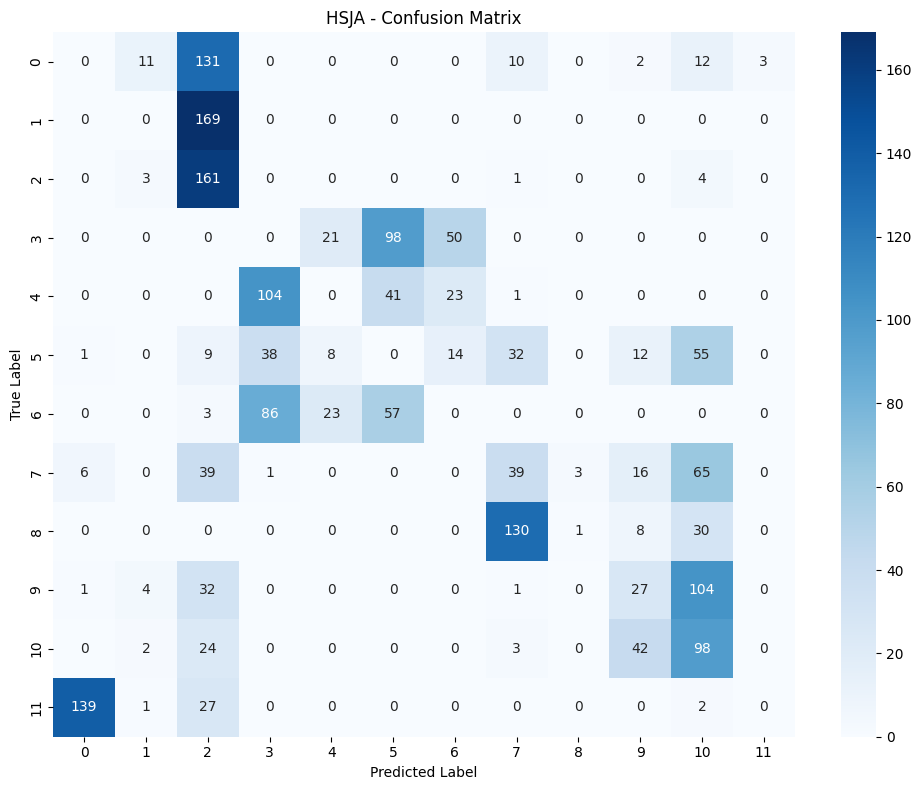

Runtime:  2839.0980989933014  seconds


In [29]:
predictions_adv = classifier.predict(HSJA_adv_samples)

evaluate_attack(y_test, predictions_adv, 'HSJA')
print("Runtime: ", time.time() - start_time, " seconds")

# Save adversarial samples as CSV
df_adv = pd.DataFrame(HSJA_adv_samples, columns=feature_names)
df_adv['Label'] = y_test
df_adv.to_csv('../../adv_samples/adv_eval/rf/rf_hsja_adv.csv', index=False)

### 4b. Fallback: Whitebox attacks via LSTM surrogate (transferability)

Load adversarial samples generated by whitebox attacks (FGSM, PGD, DeepFool, C&W, JSMA) on the LSTM model, then evaluate their transferability on RandomForest.

--- FGSM (LSTM→RF) ---
Accuracy on FGSM (LSTM→RF) adversarial examples: 49.21%
Precision on FGSM (LSTM→RF) adversarial examples: 48.96%
Recall on FGSM (LSTM→RF) adversarial examples: 49.21%
F1 Score on FGSM (LSTM→RF) adversarial examples: 0.4511


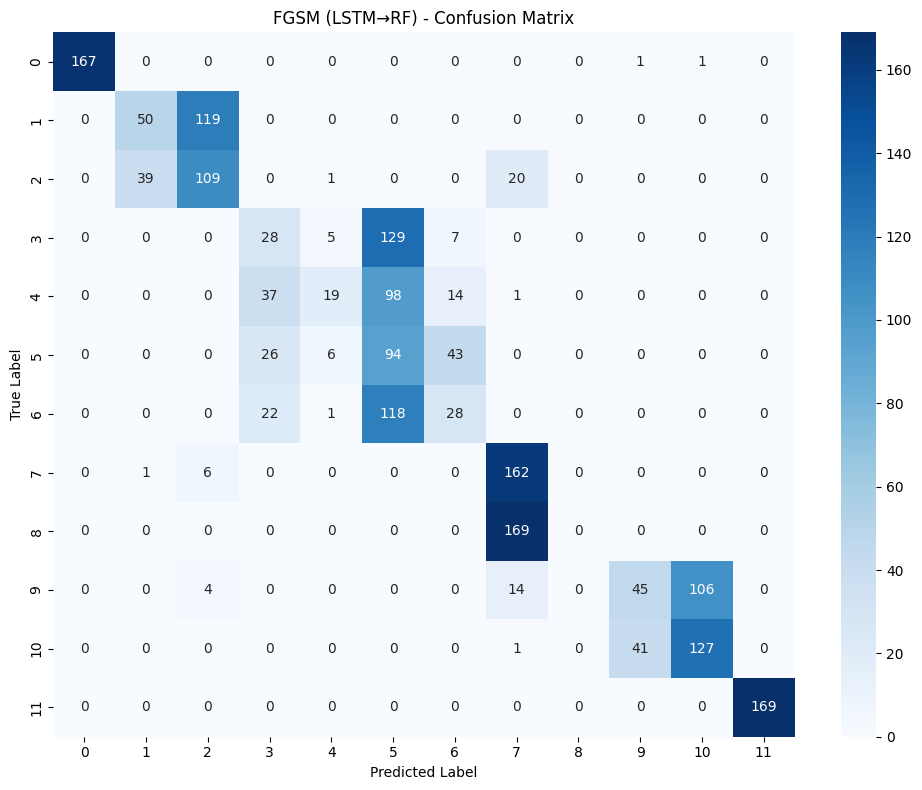

Saved: ../../adv_samples/adv_eval/rf/rf_fgsm_adv.csv

--- PGD (LSTM→RF) ---
Accuracy on PGD (LSTM→RF) adversarial examples: 55.62%
Precision on PGD (LSTM→RF) adversarial examples: 52.96%
Recall on PGD (LSTM→RF) adversarial examples: 55.62%
F1 Score on PGD (LSTM→RF) adversarial examples: 0.5093


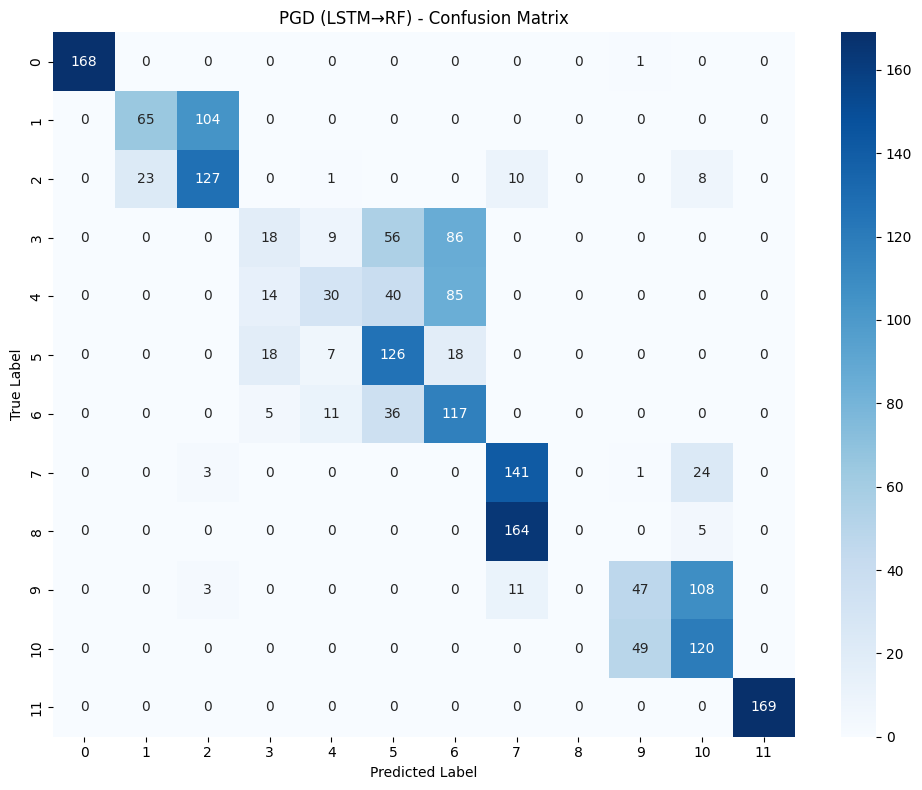

Saved: ../../adv_samples/adv_eval/rf/rf_pgd_adv.csv

--- DEEPFOOL (LSTM→RF) ---
Accuracy on DEEPFOOL (LSTM→RF) adversarial examples: 49.41%
Precision on DEEPFOOL (LSTM→RF) adversarial examples: 54.58%
Recall on DEEPFOOL (LSTM→RF) adversarial examples: 49.41%
F1 Score on DEEPFOOL (LSTM→RF) adversarial examples: 0.4659


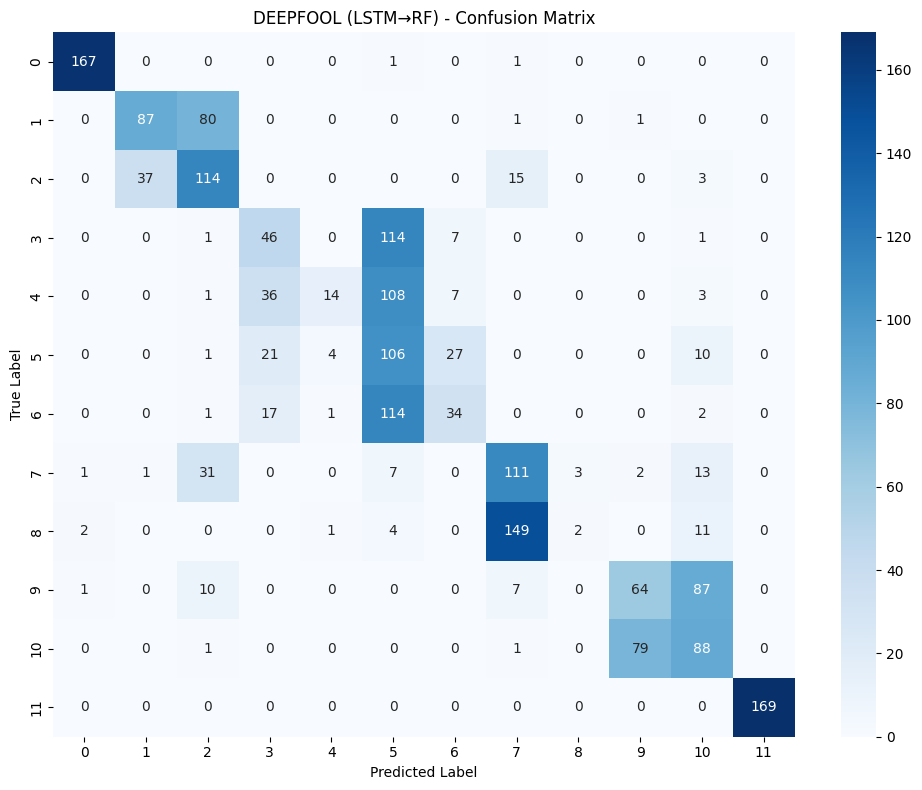

Saved: ../../adv_samples/adv_eval/rf/rf_deepfool_adv.csv

--- CW (LSTM→RF) ---
Accuracy on CW (LSTM→RF) adversarial examples: 55.97%
Precision on CW (LSTM→RF) adversarial examples: 74.05%
Recall on CW (LSTM→RF) adversarial examples: 55.97%
F1 Score on CW (LSTM→RF) adversarial examples: 0.5144


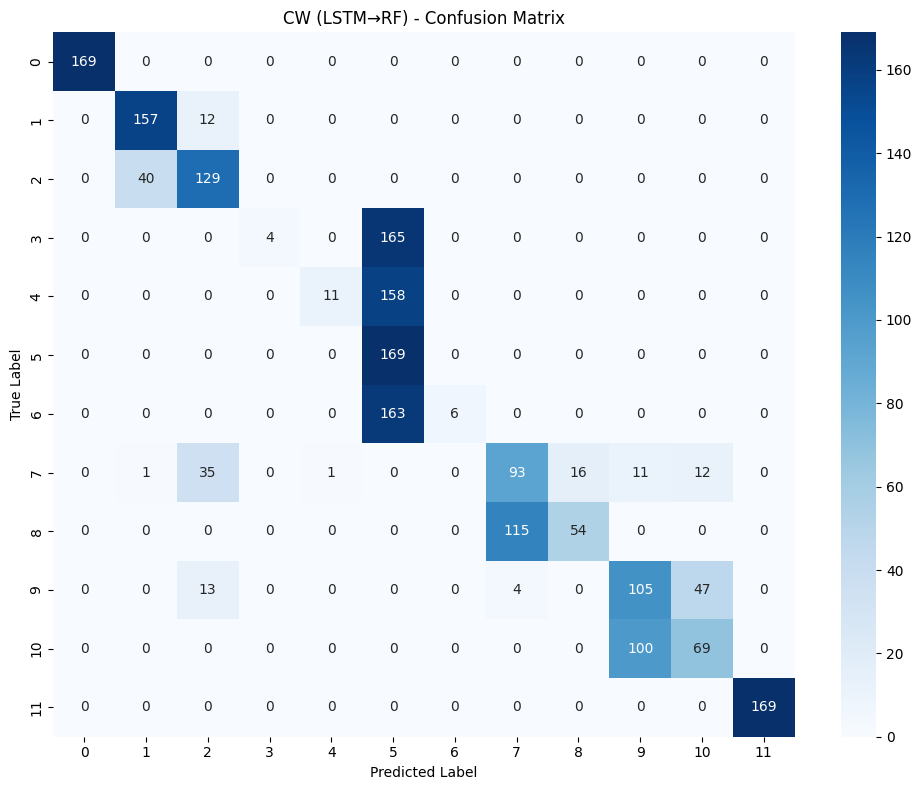

Saved: ../../adv_samples/adv_eval/rf/rf_cw_adv.csv

--- JSMA (LSTM→RF) ---
Accuracy on JSMA (LSTM→RF) adversarial examples: 77.27%
Precision on JSMA (LSTM→RF) adversarial examples: 81.35%
Recall on JSMA (LSTM→RF) adversarial examples: 77.27%
F1 Score on JSMA (LSTM→RF) adversarial examples: 0.7742


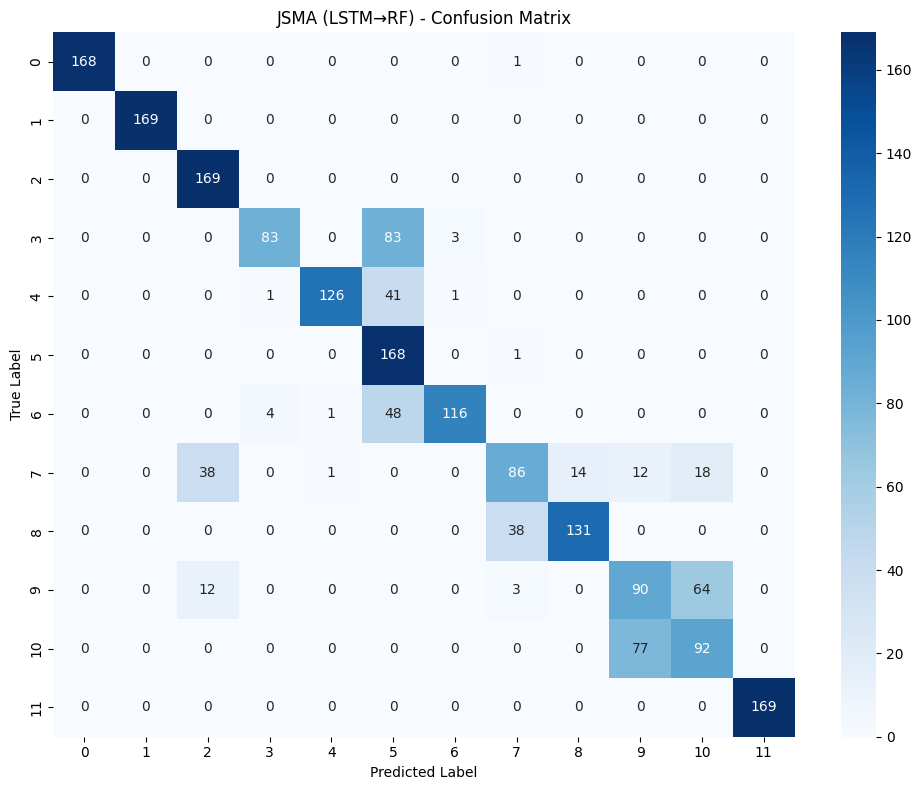

Saved: ../../adv_samples/adv_eval/rf/rf_jsma_adv.csv



In [23]:
# ── Load whitebox adversarial samples generated by LSTM (attack_LSTM.ipynb) ──
LSTM_ADV_DIR = '../../adv_samples/adv_eval/lstm'
RF_ADV_DIR = '../../adv_samples/adv_eval/rf'
os.makedirs(RF_ADV_DIR, exist_ok=True)

wb_attacks = ['fgsm', 'pgd', 'deepfool', 'cw', 'jsma']
wb_adv_samples = {}

for atk in wb_attacks:
    path = f'{LSTM_ADV_DIR}/lstm_{atk}_adv.csv'
    df_adv = pd.read_csv(path)
    adv_X = df_adv.drop(columns=['Label']).values
    wb_adv_samples[atk] = adv_X

    # Evaluate on RF classifier
    predictions_adv = classifier.predict(adv_X)
    evaluate_attack(y_test, predictions_adv, f'{atk.upper()} (LSTM→RF)')

    # Save as RF-specific CSV
    df_adv.to_csv(f'{RF_ADV_DIR}/rf_{atk}_adv.csv', index=False)
    print(f'Saved: {RF_ADV_DIR}/rf_{atk}_adv.csv\n')

FGSM_adv = wb_adv_samples['fgsm']
PGD_adv = wb_adv_samples['pgd']
DeepFool_adv = wb_adv_samples['deepfool']
CW_adv = wb_adv_samples['cw']
JSMA_adv = wb_adv_samples['jsma']

### 5. ASR (Attack Success Rate)

In [30]:
# Original predictions
predictions = classifier.predict(X_test)
y_pred_org = np.argmax(predictions, axis=1)
correct_indices = np.where(y_test == y_pred_org)[0]

# Load all adv samples from CSV
RF_ADV_DIR = '../../adv_samples/adv_eval/rf'
attack_names_map = {
    'ZOO': 'rf_zoo_adv.csv',
    'HSJA': 'rf_hsja_adv.csv',
    'FGSM (LSTM→RF)': 'rf_fgsm_adv.csv',
    'PGD (LSTM→RF)': 'rf_pgd_adv.csv',
    'DeepFool (LSTM→RF)': 'rf_deepfool_adv.csv',
    'C&W (LSTM→RF)': 'rf_cw_adv.csv',
    'JSMA (LSTM→RF)': 'rf_jsma_adv.csv',
}

print('=== RF Attack Success Rate ===')
for name, fname in attack_names_map.items():
    path = os.path.join(RF_ADV_DIR, fname)
    if os.path.exists(path):
        adv = pd.read_csv(path).drop(columns=['Label']).values.astype(np.float32)
        preds_adv = np.argmax(classifier.predict(adv), axis=1)
        asr = np.sum(y_pred_org[correct_indices] != preds_adv[correct_indices]) / len(correct_indices) * 100
        print(f'{name:>25s} ASR: {asr:.2f}%')
    else:
        print(f'{name:>25s} [SKIP] not found')

=== RF Attack Success Rate ===
                      ZOO ASR: 64.49%
                     HSJA ASR: 90.78%
           FGSM (LSTM→RF) ASR: 51.20%
            PGD (LSTM→RF) ASR: 43.59%
       DeepFool (LSTM→RF) ASR: 49.20%
            C&W (LSTM→RF) ASR: 37.23%
           JSMA (LSTM→RF) ASR: 13.00%
